# Dust Map Coverage

Compare coverage of Marshall et al. (2006) and Bayestar19 (Green et al. 2019) dust maps.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u

from dustmaps.config import config
config["data_dir"] = "../data/dustmaps"

from dustmaps.marshall import MarshallQuery
from dustmaps.bayestar import BayestarQuery

In [2]:
marshall = MarshallQuery()
bayestar = BayestarQuery(version="bayestar2019")

Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 20.881 s
  pix_info:   0.243 s
   samples:  10.550 s
      best:   2.147 s
       nan:   0.026 s
      sort:   7.885 s
       idx:   0.031 s


## Coverage Test

Query a grid of (ell, b) at fixed distance to see where each map returns valid data.

In [4]:
# Grid of Galactic coordinates
ell_grid = np.linspace(0, 360, 361)
b_grid = np.linspace(-90, 90, 181)
ell_mesh, b_mesh = np.meshgrid(ell_grid, b_grid)

# Fixed distance for testing
dist_kpc = 2.0

coords = SkyCoord(
    l=ell_mesh.ravel() * u.deg,
    b=b_mesh.ravel() * u.deg,
    distance=dist_kpc * u.kpc,
    frame="galactic"
)

In [5]:
# Query Marshall (returns NaN outside coverage)
A_marshall = marshall(coords)
A_marshall = A_marshall.reshape(ell_mesh.shape)
marshall_valid = ~np.isnan(A_marshall)

print(f"Marshall coverage: {marshall_valid.sum() / marshall_valid.size * 100:.1f}% of sky")

Marshall coverage: 6.5% of sky


In [6]:
# Query Bayestar (returns NaN outside coverage)
A_bayestar = bayestar(coords, mode="mean")
A_bayestar = A_bayestar.reshape(ell_mesh.shape)
bayestar_valid = ~np.isnan(A_bayestar)

print(f"Bayestar coverage: {bayestar_valid.sum() / bayestar_valid.size * 100:.1f}% of sky")

Bayestar coverage: 79.0% of sky


## Sky Coverage Plot

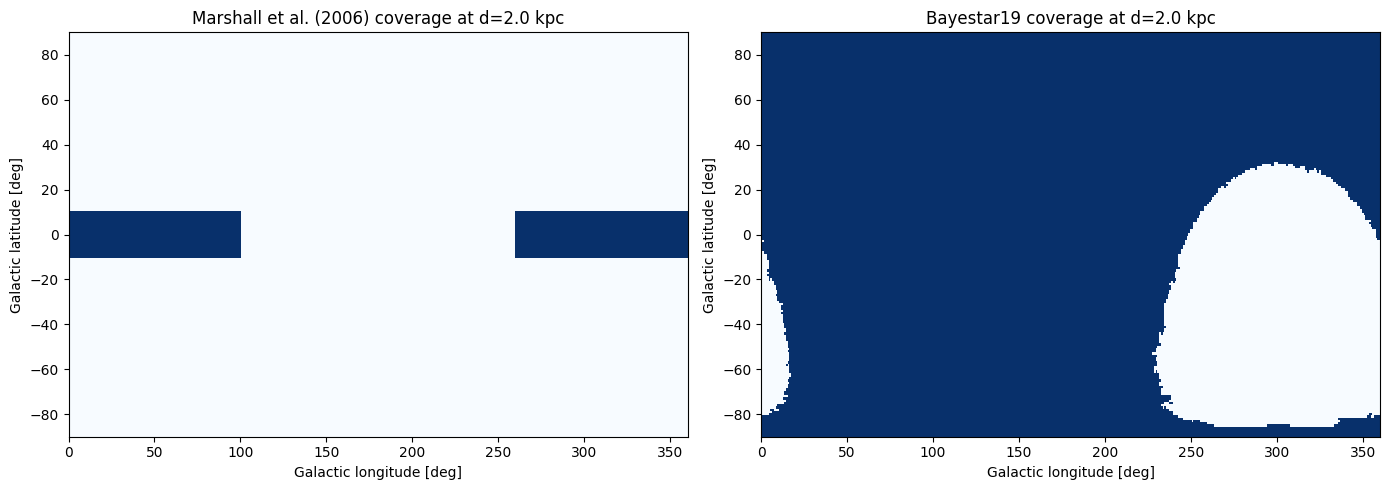

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Marshall coverage
ax = axes[0]
im = ax.pcolormesh(ell_grid, b_grid, marshall_valid.astype(float), 
                   cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("Galactic longitude [deg]")
ax.set_ylabel("Galactic latitude [deg]")
ax.set_title(f"Marshall et al. (2006) coverage at d={dist_kpc} kpc")
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)

# Bayestar coverage
ax = axes[1]
im = ax.pcolormesh(ell_grid, b_grid, bayestar_valid.astype(float),
                   cmap="Blues", vmin=0, vmax=1)
ax.set_xlabel("Galactic longitude [deg]")
ax.set_ylabel("Galactic latitude [deg]")
ax.set_title(f"Bayestar19 coverage at d={dist_kpc} kpc")
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)

plt.tight_layout()
plt.show()

## Combined Coverage

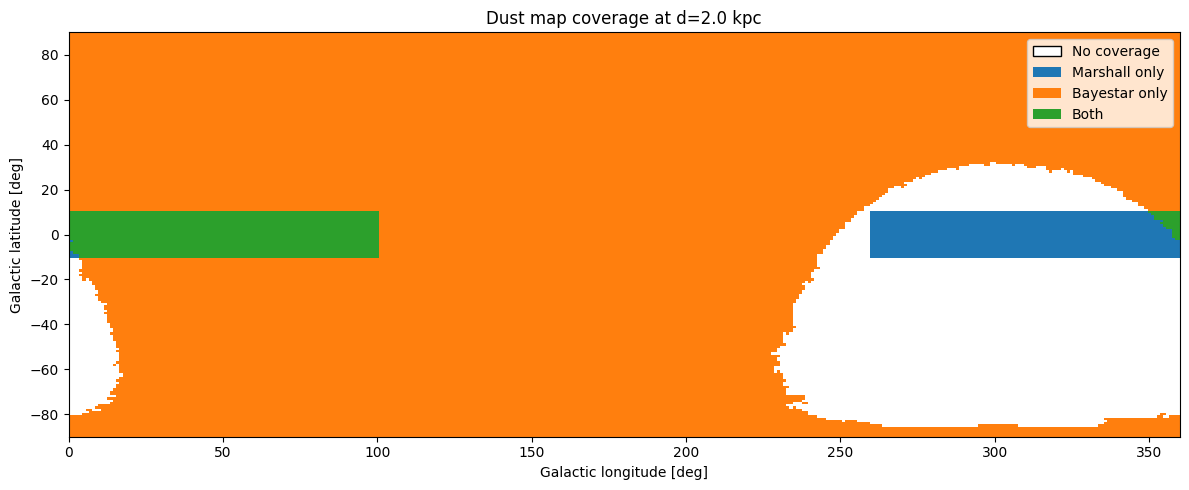

In [8]:
# 0 = no coverage, 1 = Marshall only, 2 = Bayestar only, 3 = both
combined = marshall_valid.astype(int) + 2 * bayestar_valid.astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.colors.ListedColormap(["white", "C0", "C1", "C2"])
im = ax.pcolormesh(ell_grid, b_grid, combined, cmap=cmap, vmin=0, vmax=3)
ax.set_xlabel("Galactic longitude [deg]")
ax.set_ylabel("Galactic latitude [deg]")
ax.set_title(f"Dust map coverage at d={dist_kpc} kpc")
ax.set_xlim(0, 360)
ax.set_ylim(-90, 90)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="white", edgecolor="black", label="No coverage"),
    Patch(facecolor="C0", label="Marshall only"),
    Patch(facecolor="C1", label="Bayestar only"),
    Patch(facecolor="C2", label="Both"),
]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.show()

## Check Coverage for Sample Stars

In [9]:
# Load Cepheid data
import sys
sys.path.insert(0, "..")
from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config

cfg = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
data = CepheidData(cfg)

2026-02-10 20:35:32 ============================================================
2026-02-10 20:35:32 Model Configuration
2026-02-10 20:35:32 ============================================================
2026-02-10 20:35:32   Model type      : forward
2026-02-10 20:35:32   Distance prior  : disk
2026-02-10 20:35:32 ------------------------------------------------------------
2026-02-10 20:35:32 C22 Selection
2026-02-10 20:35:32 ------------------------------------------------------------
2026-02-10 20:35:32   mW selection    : ENABLED
2026-02-10 20:35:32   mW_max          : 7.500
2026-02-10 20:35:32   mW_width        : 0.500
2026-02-10 20:35:32   AH selection    : disabled
2026-02-10 20:35:32   pi selection    : ENABLED
2026-02-10 20:35:32   pi_min          : 0.350
2026-02-10 20:35:32   pi_smooth       : True
2026-02-10 20:35:32   pi_width        : 0.1
2026-02-10 20:35:32   Distance grid   : [0.1, 8.0] kpc, n=159, dx=0.05
2026-02-10 20:35:32   MC selection    : 500
2026-02-10 20:35:32   

In [10]:
# Extinction as a function of distance for sample stars
ell = np.asarray(data.ell)
b = np.asarray(data.b)
d_obs = 1.0 / np.asarray(data.pi_EDR3)  # Approximate distance from parallax

# Distance grid
d_grid = np.linspace(0.1, 5.0, 50)

# Query extinction at each distance for each star
n_stars = len(ell)
A_marshall_grid = np.zeros((n_stars, len(d_grid)))
A_bayestar_grid = np.zeros((n_stars, len(d_grid)))
A_bayestar_std_grid = np.zeros((n_stars, len(d_grid)))

for i, d in enumerate(d_grid):
    coords = SkyCoord(l=ell * u.deg, b=b * u.deg, distance=d * u.kpc, frame="galactic")
    A_marshall_grid[:, i] = marshall(coords)
    A_bayestar_grid[:, i] = bayestar(coords, mode="mean")
    samples = bayestar(coords, mode="samples")
    A_bayestar_std_grid[:, i] = np.nanstd(samples, axis=-1)

/mnt/users/rstiskalek/CANDEL/venv_candel/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


<>:20: SyntaxWarning: invalid escape sequence '\p'
<>:20: SyntaxWarning: invalid escape sequence '\p'
/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_30871/1930655109.py:20: SyntaxWarning: invalid escape sequence '\p'
  ax.set_title("Bayestar19 reddening profiles ($\pm 1\sigma$)")


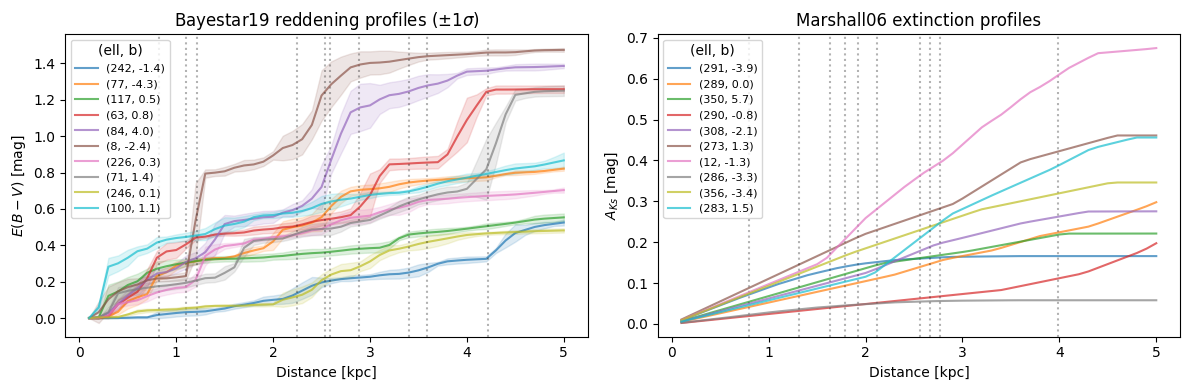

Dotted lines show observed distance from parallax
Note: Bayestar returns E(B-V), Marshall returns A_Ks
Shaded bands show ±1σ from Bayestar19 posterior samples


In [11]:
# Plot extinction vs distance for a few example stars
# Note: Bayestar returns E(B-V), Marshall returns A_Ks
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pick ~10 random stars with valid Bayestar coverage
valid_idx = np.where(~np.isnan(A_bayestar_grid[:, -1]))[0]
sample_idx = np.random.choice(valid_idx, size=min(10, len(valid_idx)), replace=False)

ax = axes[0]
for idx in sample_idx:
    line, = ax.plot(d_grid, A_bayestar_grid[idx], alpha=0.7, 
            label=f"({ell[idx]:.0f}, {b[idx]:.1f})")
    ax.fill_between(d_grid,
                    A_bayestar_grid[idx] - A_bayestar_std_grid[idx],
                    A_bayestar_grid[idx] + A_bayestar_std_grid[idx],
                    alpha=0.15, color=line.get_color())
    ax.axvline(d_obs[idx], color="k", ls=":", alpha=0.3)
ax.set_xlabel("Distance [kpc]")
ax.set_ylabel(r"$E(B-V)$ [mag]")  # Bayestar returns E(B-V)
ax.set_title("Bayestar19 reddening profiles ($\pm 1\sigma$)")
ax.legend(fontsize=8, title="(ell, b)")

# Same for Marshall (where valid)
ax = axes[1]
valid_idx_m = np.where(~np.isnan(A_marshall_grid[:, -1]))[0]
if len(valid_idx_m) > 0:
    sample_idx_m = np.random.choice(valid_idx_m, size=min(10, len(valid_idx_m)), replace=False)
    for idx in sample_idx_m:
        ax.plot(d_grid, A_marshall_grid[idx], alpha=0.7,
                label=f"({ell[idx]:.0f}, {b[idx]:.1f})")
        ax.axvline(d_obs[idx], color="k", ls=":", alpha=0.3)
ax.set_xlabel("Distance [kpc]")
ax.set_ylabel(r"$A_{Ks}$ [mag]")  # Marshall returns A_Ks
ax.set_title("Marshall06 extinction profiles")
ax.legend(fontsize=8, title="(ell, b)")

plt.tight_layout()
plt.show()

print("Dotted lines show observed distance from parallax")
print("Note: Bayestar returns E(B-V), Marshall returns A_Ks")
print("Shaded bands show ±1σ from Bayestar19 posterior samples")

In [12]:
# Coverage statistics at observed distances
star_coords = SkyCoord(l=ell * u.deg, b=b * u.deg, distance=d_obs * u.kpc, frame="galactic")
A_m = marshall(star_coords)
A_b = bayestar(star_coords, mode="mean")
A_b_samples = bayestar(star_coords, mode="samples")
A_b_std = np.nanstd(A_b_samples, axis=-1)

m_valid = ~np.isnan(A_m)
b_valid = ~np.isnan(A_b)

print(f"Stars with Marshall coverage: {m_valid.sum()}/{len(ell)} ({100*m_valid.mean():.1f}%)")
print(f"Stars with Bayestar coverage: {b_valid.sum()}/{len(ell)} ({100*b_valid.mean():.1f}%)")
print(f"Stars with either coverage:   {(m_valid | b_valid).sum()}/{len(ell)}")

Stars with Marshall coverage: 45/66 (68.2%)
Stars with Bayestar coverage: 32/66 (48.5%)
Stars with either coverage:   64/66


In [13]:
# Convert to A_H - NOTE: maps return different quantities!
# Marshall returns A_Ks, Bayestar returns reddening in arbitrary units

# Marshall: A_H = 1.55 × A_Ks (Nishiyama et al. 2009)
AKS_TO_AH = 1.55
A_H_marshall = AKS_TO_AH * A_m

# Bayestar: A_H = R_H × E, where R_H = 0.469 (Green et al. 2019, Table 1)
R_H_BAYESTAR = 0.469
A_H_bayestar = R_H_BAYESTAR * A_b
A_H_bayestar_std = R_H_BAYESTAR * A_b_std

print("Conversion factors:")
print(f"  Marshall (A_Ks → A_H): × {AKS_TO_AH}")
print(f"  Bayestar (reddening → A_H): × {R_H_BAYESTAR} (Green et al. 2019)")

# Bayestar A_H posterior std statistics
b_std_valid = A_H_bayestar_std[b_valid]
print(f"\nBayestar19 A_H posterior std (at observed distances):")
print(f"  Stars with coverage: {b_valid.sum()}")
print(f"  Median std: {np.median(b_std_valid):.4f} mag")
print(f"  Mean std:   {np.mean(b_std_valid):.4f} mag")
print(f"  Max std:    {np.max(b_std_valid):.4f} mag")
print(f"  Fractional (median): {np.median(b_std_valid / A_H_bayestar[b_valid]):.1%}")

# Stars with both maps available
both_valid = m_valid & b_valid
print(f"\nStars with both Marshall and Bayestar: {both_valid.sum()}")

if both_valid.sum() > 0:
    diff = A_H_marshall[both_valid] - A_H_bayestar[both_valid]
    print(f"\nA_H(Marshall) - A_H(Bayestar) for stars with both:")
    print(f"  Mean difference: {np.mean(diff):.3f} mag")
    print(f"  Std difference:  {np.std(diff):.3f} mag")
    print(f"  Range: [{np.min(diff):.3f}, {np.max(diff):.3f}] mag")
    print(f"  Bayestar posterior std (same stars): "
          f"median={np.median(A_H_bayestar_std[both_valid]):.4f} mag")

Conversion factors:
  Marshall (A_Ks → A_H): × 1.55
  Bayestar (reddening → A_H): × 0.469 (Green et al. 2019)

Bayestar19 A_H posterior std (at observed distances):
  Stars with coverage: 32
  Median std: 0.0091 mag
  Mean std:   0.0104 mag
  Max std:    0.0387 mag
  Fractional (median): 4.9%

Stars with both Marshall and Bayestar: 13

A_H(Marshall) - A_H(Bayestar) for stars with both:
  Mean difference: -0.009 mag
  Std difference:  0.147 mag
  Range: [-0.390, 0.253] mag
  Bayestar posterior std (same stars): median=0.0094 mag


<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_30871/2830930186.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.suptitle("Bayestar shaded = $\pm 1\sigma$ posterior", fontsize=10, y=1.01)


Plotting extinction profiles for 13 stars with both maps


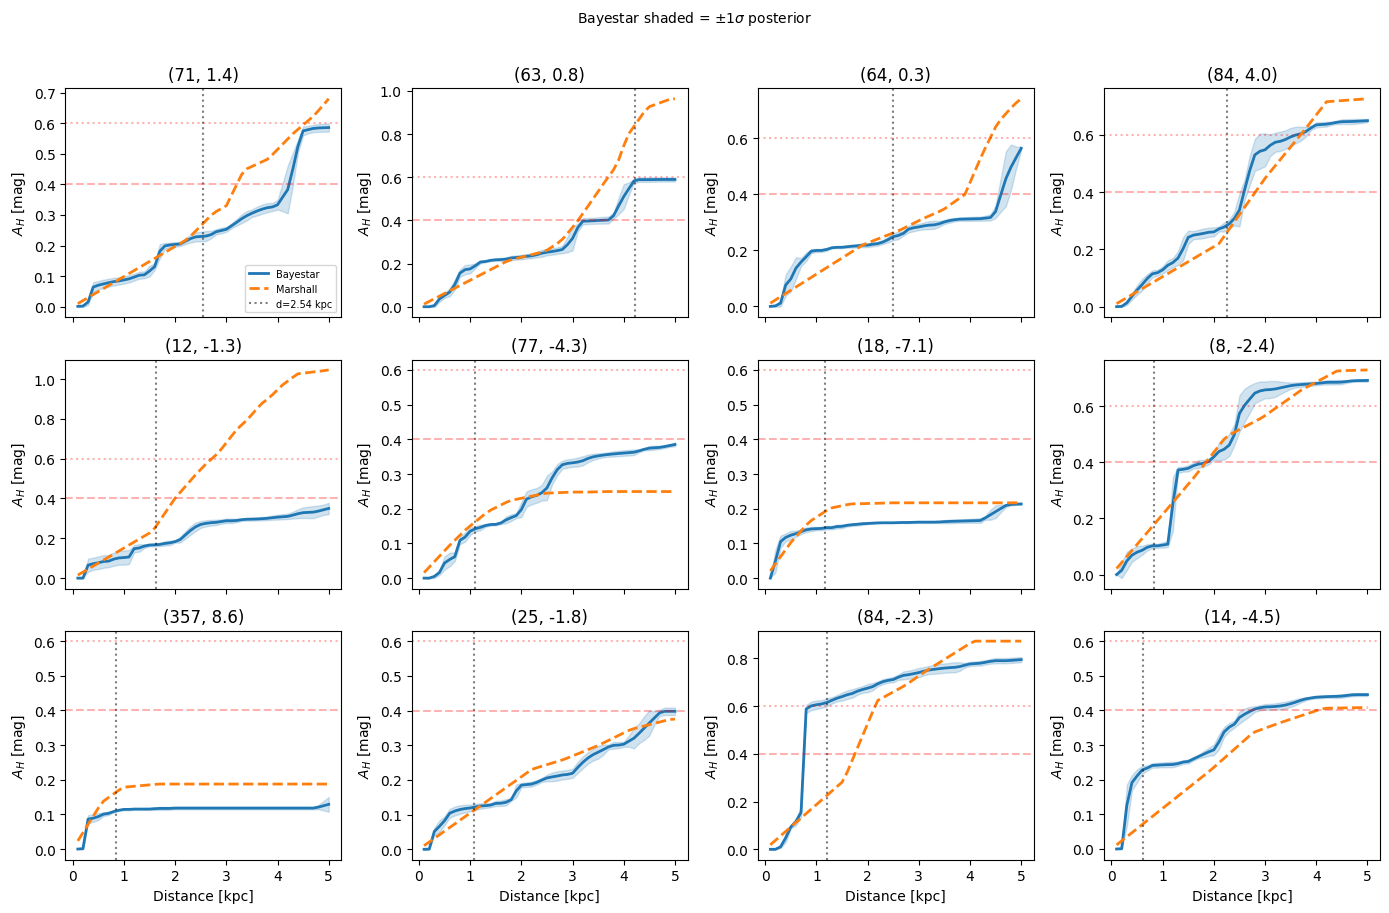

In [14]:
# Plot extinction profiles for stars with BOTH Marshall and Bayestar coverage
both_idx = np.where(both_valid)[0]
print(f"Plotting extinction profiles for {len(both_idx)} stars with both maps")

n_plot = min(12, len(both_idx))
ncols = 4
nrows = int(np.ceil(n_plot / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=True)
axes = axes.ravel()

for i, idx in enumerate(both_idx[:n_plot]):
    ax = axes[i]
    
    # Convert to A_H using correct factors for each map
    A_H_m = AKS_TO_AH * A_marshall_grid[idx]       # Marshall returns A_Ks
    A_H_b = R_H_BAYESTAR * A_bayestar_grid[idx]   # Bayestar returns reddening
    A_H_b_std = R_H_BAYESTAR * A_bayestar_std_grid[idx]
    
    line_b, = ax.plot(d_grid, A_H_b, label="Bayestar", lw=2)
    ax.fill_between(d_grid, A_H_b - A_H_b_std, A_H_b + A_H_b_std,
                    alpha=0.2, color=line_b.get_color())
    ax.plot(d_grid, A_H_m, label="Marshall", lw=2, ls="--")
    ax.axvline(d_obs[idx], color="k", ls=":", alpha=0.5, label=f"d={d_obs[idx]:.2f} kpc")
    ax.axhline(0.4, color="r", ls="--", alpha=0.3)
    ax.axhline(0.6, color="r", ls=":", alpha=0.3)
    
    ax.set_title(f"({ell[idx]:.0f}, {b[idx]:.1f})")
    ax.set_ylabel(r"$A_H$ [mag]")
    if i == 0:
        ax.legend(fontsize=7)

# Hide empty subplots
for i in range(n_plot, len(axes)):
    axes[i].set_visible(False)

for ax in axes[ncols * (nrows - 1):ncols * nrows]:
    if ax.get_visible():
        ax.set_xlabel("Distance [kpc]")

plt.suptitle("Bayestar shaded = $\pm 1\sigma$ posterior", fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Summary: compare to R21 selection limits
print("Comparison with R21 selection limits:")
print("=" * 50)

# Use Bayestar where available, else Marshall
A_H_best = np.where(b_valid, A_H_bayestar, A_H_marshall)
any_valid = m_valid | b_valid

print(f"\nUsing Bayestar (preferred) or Marshall as fallback:")
print(f"  Stars with A_H < 0.4 mag: {np.sum(A_H_best[any_valid] < 0.4)}/{any_valid.sum()}")
print(f"  Stars with A_H < 0.6 mag: {np.sum(A_H_best[any_valid] < 0.6)}/{any_valid.sum()}")
print(f"  Stars with A_H >= 0.6 mag: {np.sum(A_H_best[any_valid] >= 0.6)}/{any_valid.sum()}")

if any_valid.sum() > 0:
    print(f"\n  A_H range: [{np.nanmin(A_H_best[any_valid]):.3f}, {np.nanmax(A_H_best[any_valid]):.3f}] mag")
    print(f"  A_H median: {np.nanmedian(A_H_best[any_valid]):.3f} mag")

# Stars exceeding R21 limits
high_ext = any_valid & (A_H_best >= 0.6)
if high_ext.sum() > 0:
    print(f"\nStars with A_H >= 0.6 mag (exceeding R21 limits):")
    for i in np.where(high_ext)[0]:
        src = "Bayestar" if b_valid[i] else "Marshall"
        std_str = f", std={A_H_bayestar_std[i]:.3f}" if b_valid[i] else ""
        print(f"  Star {i}: (ell={ell[i]:.1f}, b={b[i]:.1f}), "
              f"A_H={A_H_best[i]:.3f} mag ({src}{std_str})")

# Bayestar std summary across the distance grid
print(f"\nBayestar19 A_H posterior std (grid profiles):")
AH_std_grid = R_H_BAYESTAR * A_bayestar_std_grid
valid_mask = ~np.isnan(R_H_BAYESTAR * A_bayestar_grid)
grid_std_valid = AH_std_grid[valid_mask]
print(f"  Grid points with coverage: {valid_mask.sum()}")
print(f"  Median std: {np.median(grid_std_valid):.4f} mag")
print(f"  Mean std:   {np.mean(grid_std_valid):.4f} mag")
print(f"  90th pctl:  {np.percentile(grid_std_valid, 90):.4f} mag")
print(f"  Max std:    {np.max(grid_std_valid):.4f} mag")

Comparison with R21 selection limits:

Using Bayestar (preferred) or Marshall as fallback:
  Stars with A_H < 0.4 mag: 59/64
  Stars with A_H < 0.6 mag: 62/64
  Stars with A_H >= 0.6 mag: 2/64

  A_H range: [0.054, 1.035] mag
  A_H median: 0.163 mag

Stars with A_H >= 0.6 mag (exceeding R21 limits):
  Star 8: (ell=285.7, b=-0.4), A_H=1.035 mag (Marshall)
  Star 58: (ell=84.3, b=-2.3), A_H=0.616 mag (Bayestar, std=0.017)

Bayestar19 A_H posterior std (grid profiles):
  Grid points with coverage: 1600
  Median std: 0.0091 mag
  Mean std:   0.0110 mag
  90th pctl:  0.0195 mag
  Max std:    0.0981 mag


In [16]:
# Bayestar std and Marshall-Bayestar difference at specific distances
AH_b_grid = R_H_BAYESTAR * A_bayestar_grid
AH_b_std_grid = R_H_BAYESTAR * A_bayestar_std_grid
AH_m_grid = AKS_TO_AH * A_marshall_grid

for d_eval in [4.0, 5.0]:
    idx_d = np.argmin(np.abs(d_grid - d_eval))
    print(f"{'=' * 55}")
    print(f"  d = {d_grid[idx_d]:.2f} kpc")
    print(f"{'=' * 55}")

    # Bayestar A_H std at this distance
    b_valid_d = np.isfinite(AH_b_grid[:, idx_d])
    if b_valid_d.sum() > 0:
        std_vals = AH_b_std_grid[b_valid_d, idx_d]
        print(f"  Bayestar A_H posterior std ({b_valid_d.sum()} stars):")
        print(f"    Median: {np.median(std_vals):.4f} mag")
        print(f"    Mean:   {np.mean(std_vals):.4f} mag")
        print(f"    Max:    {np.max(std_vals):.4f} mag")

    # Marshall - Bayestar difference at this distance
    m_valid_d = np.isfinite(AH_m_grid[:, idx_d])
    both_d = b_valid_d & m_valid_d
    if both_d.sum() > 0:
        diff = AH_m_grid[both_d, idx_d] - AH_b_grid[both_d, idx_d]
        print(f"  A_H(Marshall) - A_H(Bayestar) ({both_d.sum()} stars):")
        print(f"    Mean diff: {np.mean(diff):.4f} mag")
        print(f"    Std diff:  {np.std(diff):.4f} mag")
        print(f"    Range:     [{np.min(diff):.4f}, {np.max(diff):.4f}] mag")
    else:
        print(f"  No stars with both maps at this distance.")
    print()

  d = 4.00 kpc
  Bayestar A_H posterior std (32 stars):
    Median: 0.0092 mag
    Mean:   0.0125 mag
    Max:    0.0711 mag
  A_H(Marshall) - A_H(Bayestar) (13 stars):
    Mean diff: 0.0929 mag
    Std diff:  0.1851 mag
    Range:     [-0.1109, 0.6399] mag

  d = 5.00 kpc
  Bayestar A_H posterior std (32 stars):
    Median: 0.0105 mag
    Mean:   0.0121 mag
    Max:    0.0396 mag
  A_H(Marshall) - A_H(Bayestar) (13 stars):
    Mean diff: 0.0985 mag
    Std diff:  0.2129 mag
    Range:     [-0.1356, 0.6958] mag



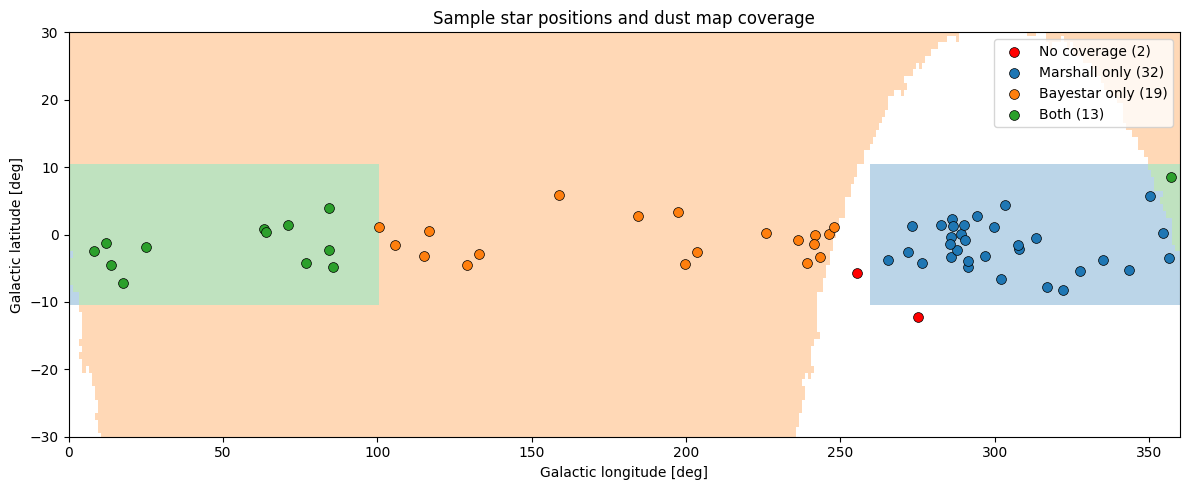


Summary: 13 stars with both, 32 Marshall only, 19 Bayestar only, 2 no coverage


In [17]:
# Plot star positions with dust map coverage
fig, ax = plt.subplots(figsize=(12, 5))

# Background: combined coverage at 2 kpc
ax.pcolormesh(ell_grid, b_grid, combined, cmap=cmap, vmin=0, vmax=3, alpha=0.3)

# Stars colored by coverage
both = m_valid & b_valid
m_only = m_valid & ~b_valid
b_only = ~m_valid & b_valid
neither = ~m_valid & ~b_valid

ax.scatter(ell[neither], b[neither], c="red", s=50, edgecolor="k", lw=0.5,
           label=f"No coverage ({neither.sum()})", zorder=10)
ax.scatter(ell[m_only], b[m_only], c="C0", s=50, edgecolor="k", lw=0.5,
           label=f"Marshall only ({m_only.sum()})", zorder=10)
ax.scatter(ell[b_only], b[b_only], c="C1", s=50, edgecolor="k", lw=0.5,
           label=f"Bayestar only ({b_only.sum()})", zorder=10)
ax.scatter(ell[both], b[both], c="C2", s=50, edgecolor="k", lw=0.5,
           label=f"Both ({both.sum()})", zorder=10)

ax.set_xlabel("Galactic longitude [deg]")
ax.set_ylabel("Galactic latitude [deg]")
ax.set_title("Sample star positions and dust map coverage")
ax.legend(loc="upper right")
ax.set_xlim(0, 360)
ax.set_ylim(-30, 30)

plt.tight_layout()
plt.show()

print(f"\nSummary: {both.sum()} stars with both, {m_only.sum()} Marshall only, "
      f"{b_only.sum()} Bayestar only, {neither.sum()} no coverage")

## Marshall vs Bayestar A_H difference per campaign

In [ ]:
# Reload full data (both campaigns)
import copy
cfg_all = copy.deepcopy(cfg)
cfg_all["data"].pop("which_subset", None)
data_all = CepheidData(cfg_all)
campaigns = data_all.split_by_campaign()

delta_pi = -0.014  # Parallax zero-point offset [mas]

for name, d in campaigns.items():
    ell_c = np.asarray(d.ell)
    b_c = np.asarray(d.b)
    pi_c = np.asarray(d.pi_EDR3)
    d_c = 1.0 / (pi_c - delta_pi)  # corrected parallax: pi_true = pi_obs - delta_pi

    coords_c = SkyCoord(l=ell_c * u.deg, b=b_c * u.deg,
                         distance=d_c * u.kpc, frame="galactic")

    A_m_c = marshall(coords_c)
    samples_c = bayestar(coords_c, mode="samples")
    A_b_c = np.nanmean(samples_c, axis=-1)
    A_b_std_c = np.nanstd(samples_c, axis=-1)

    # Convert to A_H
    AH_m = AKS_TO_AH * A_m_c
    AH_b = R_H_BAYESTAR * A_b_c
    AH_b_std = R_H_BAYESTAR * A_b_std_c

    m_ok = np.isfinite(AH_m)
    b_ok = np.isfinite(AH_b)
    both_ok = m_ok & b_ok

    print(f"{'=' * 55}")
    print(f"  {name} ({len(ell_c)} stars, delta_pi = {delta_pi} mas)")
    print(f"{'=' * 55}")
    print(f"  Marshall coverage: {m_ok.sum()}/{len(ell_c)}")
    print(f"  Bayestar coverage: {b_ok.sum()}/{len(ell_c)}")
    print(f"  Both:              {both_ok.sum()}/{len(ell_c)}")

    if b_ok.sum() > 0:
        print(f"\n  Bayestar A_H posterior std ({b_ok.sum()} stars):")
        print(f"    Median: {np.median(AH_b_std[b_ok]):.4f} mag")
        print(f"    Mean:   {np.mean(AH_b_std[b_ok]):.4f} mag")
        print(f"    Max:    {np.max(AH_b_std[b_ok]):.4f} mag")

    if both_ok.sum() > 0:
        diff = AH_m[both_ok] - AH_b[both_ok]
        print(f"\n  A_H(Marshall) - A_H(Bayestar) ({both_ok.sum()} stars):")
        print(f"    Mean: {np.mean(diff):.4f} mag")
        print(f"    Std:  {np.std(diff):.4f} mag")
        print(f"    Range: [{np.min(diff):.4f}, {np.max(diff):.4f}] mag")
    else:
        print(f"\n  No stars with both maps.")
    print()

2026-02-10 20:36:43 Dropping 7 stars without EDR3: CY-AUR, DL-CAS, RW-CAM, SV-PER, SY-NOR, RX-CAM, U-AQL
2026-02-10 20:36:43 Loaded 67 stars from /mnt/users/rstiskalek/CANDEL/data/Riess2021_Table1_with_coords.csv
2026-02-10 20:36:43 C22 pi > 0.0: 44/44 C22 stars kept
2026-02-10 20:36:43 C27 pi > 0.79: 22/23 C27 stars kept
2026-02-10 20:36:43 Final sample: 66 stars (44 C22 + 22 C27)
2026-02-10 20:36:43 Loaded 443 NGC4258 Cepheids from /mnt/users/rstiskalek/CANDEL/data/SH0ES_N4258_Cepheids.csv
2026-02-10 20:36:43   Covariance matrix: (443, 443)
2026-02-10 20:36:43 Loaded 482 LMC Cepheids from /mnt/users/rstiskalek/CANDEL/data/SH0ES_LMC_Cepheids.csv
2026-02-10 20:36:43   Covariance matrix: (482, 482)
  C22 (44 stars, delta_pi = -0.014 mas)
  Marshall coverage: 27/44
  Bayestar coverage: 24/44
  Both:              7/44

  Bayestar A_H posterior std (24 stars):
    Median: 0.0098 mag
    Mean:   0.0128 mag
    Max:    0.0620 mag

  A_H(Marshall) - A_H(Bayestar) (7 stars):
    Mean: 0.0549 m

/var/folders/kv/90qm_jx508j4zhvy56lhf09m0000gn/T/ipykernel_30871/3980592954.py:21: RuntimeWarning: Mean of empty slice
  A_b_c = np.nanmean(samples_c, axis=-1)


: 